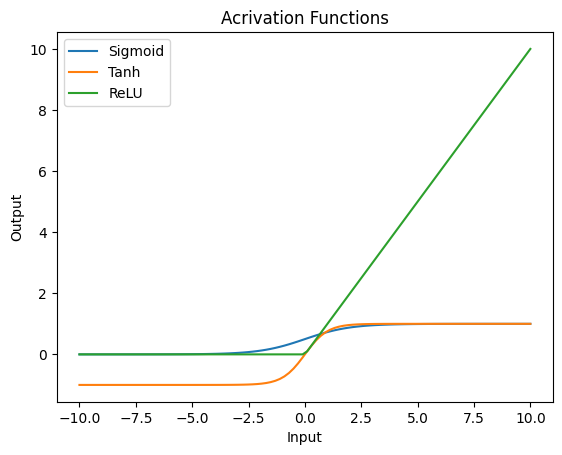

In [1]:
#Study of Activation Functions in Artificial Neural Network
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.plot(x, relu, label='ReLU')
plt.title("Acrivation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()

In [3]:
#Customer Churn Prediction Using an Activation Function
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Define the Dataset
data = {
    'Age': [22, 45, 30, 52, 28, 40, 35, 60, 25, 48,
            33, 55, 29, 42, 38, 50, 24, 57, 31, 46],

    'MonthlyCharges': [30, 80, 45, 90, 35, 70, 55, 95, 40, 85,
                       50, 88, 42, 75, 60, 82, 32, 92, 48, 78],

    'Tenure': [2, 36, 12, 48, 5, 30, 18, 60, 7, 42,
               20, 50, 10, 32, 25, 45, 3, 55, 15, 38],

    'SupportCalls': [5, 1, 4, 0, 6, 2, 3, 0, 5, 1,
                     4, 0, 6, 2, 3, 1, 7, 0, 4, 2],

    'Churn': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
              1, 0, 1, 0, 0, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

# 2. Preprocess the Data
X = df[['Age', 'MonthlyCharges', 'Tenure', 'SupportCalls']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Build the Model (Updated with Input layer)
model = Sequential([
    Input(shape=(4,)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 4. Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Model
model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0
)

# 6. Evaluate and Predict
probability = model.predict(X_test, verbose=0)
prediction = (probability >= 0.5).astype(int)
accuracy = accuracy_score(y_test, prediction)

print("Predicted Values:")
print(prediction.flatten())

print("\nActual Values:")
print(y_test.values)

Predicted Values:
[1 0 0 0 1]

Actual Values:
[1 0 0 0 1]
